# EDA – Rotten Tomatoes Movies
Análisis exploratorio del dataset de Rotten Tomatoes: 16 638 películas con puntuaciones de crítica y público, géneros, estudios y fechas de estreno.

- **Fase A (dato crudo, secciones 2 a 10):** exploración y diagnóstico de calidad del dato (nulos, duplicados, distribuciones, posibles sesgos y outliers).
- **Fase B (dato limpio, secciones 11 a 13):** análisis para interpretación final y respuesta de negocio tras aplicar limpieza reproducible y features.


**Flujo del análisis:**
1. Carga y exploración inicial del dato crudo
2. Detección de nulos, duplicados y problemas de calidad
3. Visualizaciones diagnósticas sobre el dato crudo
4. Limpieza y transformación en `src/cleaning.py`
5. Construcción de 3 features nuevas en `src/features.py`
6. Visualizaciones y conclusiones finales sobre el dato limpio con features

## 1. Importar librerías
Stack estándar de análisis: `pandas` para manipulación, `numpy` para cálculos numéricos, `matplotlib` + `seaborn` para visualizaciones.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
print(sys.executable)

e:\Programming\proyecto\pandas_data_visualization_project\project_demo\.venv\Scripts\python.exe


## 2. Cargar el dataset
Cargamos el CSV tal como viene de la fuente (sin ninguna transformación) para explorar el dato crudo antes de cualquier limpieza.

In [4]:
# Path to the Rotten Tomatoes dataset
file_path = '../data/raw/Rotten Tomatoes Movies.csv'
df = pd.read_csv(file_path)
print(f"Loaded {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded 16,638 rows × 17 columns


## 3. Primeras filas
`head()` nos da una primera impresión visual: nombres de columnas, tipos de datos aparentes y si los valores tienen sentido. Es el primer paso antes de cualquier decisión de limpieza.

In [5]:
df.head()
# df.tail()

,movie_title,movie_info,critics_consensus,rating,genre,directors,writers,cast,in_theaters_date,on_streaming_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count
16633,Zoot Suit,"Based on a 1940s Los Angeles murder trial, thi...",NaN,R,"Drama, Musical & Performing Arts",Luis Valdez,Luis Valdez,"Daniel Valdez, Edward James Olmos, Charles Aid...",1981-10-02,2003-05-27,104.0,MCA Universal Home Video,Rotten,56,9,74.0,1192.0
16634,Zootopia,The modern mammal metropolis of Zootopia is a ...,The brilliantly well-rounded Zootopia offers a...,PG,"Action & Adventure, Animation, Comedy","Byron Howard, Rich Moore, Jared Bush","Jared Bush, Phil Johnston","Ginnifer Goodwin, Jason Bateman, Idris Elba, J...",2016-03-04,2016-06-07,108.0,Walt Disney Animation Studios,Certified Fresh,97,279,92.0,100946.0
16635,Zorba the Greek,If ever there was a role that Anthony Quinn wa...,NaN,NR,"Action & Adventure, Art House & International,...",NaN,NaN,"Anthony Quinn, Alan Bates, Irene Papas, Lila K...",1964-12-17,2004-08-03,142.0,Fox,Fresh,78,9,87.0,7126.0
16636,Zulu,"Filmed on a grand scale, Zulu is a rousing rec...",NaN,PG,"Classics, Drama","Cy Endfield, Cyril Endfield","Cy Endfield, John Prebble","Stanley Baker, Jack Hawkins, Ulla Jacobsson, J...",1964-06-17,2001-02-02,139.0,Paramount Pictures,Fresh,95,21,91.0,30170.0
16637,Zulu Dawn,"A prequel to Zulu, Zulu Dawn depicts the event...",NaN,PG,"Action & Adventure, Art House & International,...",Douglas Hickox,"Cy Endfield, Anthony Storey","Burt Lancaster, Peter O'Toole, Simon Ward, Joh...",1979-12-14,2005-09-27,117.0,Tango Entertainment,Rotten,57,7,62.0,4464.0


## 4. Información general
`info()` revela los tipos reales que pandas infirió: columnas de fecha cargadas como `object`, columnas numéricas con posibles nulos, etc. Esto guía las transformaciones de limpieza.

In [6]:
df.info()
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

<class 'pandas.DataFrame'>
RangeIndex: 16638 entries, 0 to 16637
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   movie_title         16638 non-null  str    
 1   movie_info          16614 non-null  str    
 2   critics_consensus   8309 non-null   str    
 3   rating              16638 non-null  str    
 4   genre               16621 non-null  str    
 5   directors           16524 non-null  str    
 6   writers             15289 non-null  str    
 7   cast                16354 non-null  str    
 8   in_theaters_date    15823 non-null  str    
 9   on_streaming_date   16636 non-null  str    
 10  runtime_in_minutes  16483 non-null  float64
 11  studio_name         16222 non-null  str    
 12  tomatometer_status  16638 non-null  str    
 13  tomatometer_rating  16638 non-null  int64  
 14  tomatometer_count   16638 non-null  int64  
 15  audience_rating     16386 non-null  float64
 16  audience_count 

## 5. Estadísticas descriptivas
`describe()` sobre variables numéricas para detectar rangos anómalos (ej. runtime de 0 min) y percentiles de las puntuaciones. `value_counts()` sobre categóricas para ver desequilibrios de clases, como que *Rotten* es el status más frecuente.

In [7]:
# Numerical variables
display(df.describe())

# Categorical variables
print("\n--- rating value counts ---")
print(df['rating'].value_counts())

print("\n--- tomatometer_status value counts ---")
print(df['tomatometer_status'].value_counts())

,runtime_in_minutes,tomatometer_rating,tomatometer_count,audience_rating,audience_count
count,16483.000000,16638.000000,16638.000000,16386.000000,1.638600e+04
mean,102.391494,60.466522,56.607104,60.470829,1.524797e+05
std,25.028011,28.587230,66.383800,20.462368,1.817736e+06
min,1.000000,0.000000,5.000000,0.000000,5.000000e+00
25%,90.000000,38.000000,12.000000,45.000000,8.642500e+02
50%,99.000000,66.000000,28.000000,62.000000,4.876500e+03
75%,111.000000,86.000000,76.000000,77.000000,2.875200e+04
max,2000.000000,100.000000,497.000000,100.000000,3.579764e+07



--- rating value counts ---
rating
R         6136
NR        4862
PG-13     2885
PG        2062
G          652
NC17        37
PG-13)       3
R)           1
Name: count, dtype: int64

--- tomatometer_status value counts ---
tomatometer_status
Rotten             7233
Fresh              6448
Certified Fresh    2957
Name: count, dtype: int64


## 6. Diagnóstico de nulos y duplicados (antes de limpiar)
En esta etapa solo auditamos calidad de dato crudo: medimos cuántos nulos y duplicados hay y en qué columnas se concentran.

**Criterio profesional:**
- Aquí se permiten gráficos y tablas **diagnósticas** para detectar problemas.
- Las afirmaciones finales (comparativas, magnitudes y conclusiones de negocio) se reportan **después** de la limpieza reproducible de la sección 11.

In [35]:
# Null values
print(f"Null values:\n{df.isnull().sum()}")

# Duplicated rows 
duplicated_mask = df.duplicated(keep=False)
duplicated_rows = df[duplicated_mask]
print(f"Duplicated rows (count): {df.duplicated().sum()}")
if duplicated_rows.empty:
    print("No duplicated rows found")
else:
    print("Exact duplicated rows:")
    display(duplicated_rows)

# Duplicated columns
duplicated_cols = df.columns[df.columns.duplicated()]
if len(duplicated_cols) == 0:
    print("Duplicated columns: none")
else:
    print(f"Duplicated columns: {duplicated_cols.tolist()}")
    print(df.loc[:, duplicated_cols].head())

Null values:
movie_title              0
movie_info              24
critics_consensus     8329
rating                   0
genre                   17
directors              114
writers               1349
cast                   284
in_theaters_date       815
on_streaming_date        2
runtime_in_minutes     155
studio_name            416
tomatometer_status       0
tomatometer_rating       0
tomatometer_count        0
audience_rating        252
audience_count         252
dtype: int64
Duplicated rows (count): 1
Exact duplicated rows:


,movie_title,movie_info,critics_consensus,rating,genre,directors,writers,cast,in_theaters_date,on_streaming_date,runtime_in_minutes,studio_name,tomatometer_status,tomatometer_rating,tomatometer_count,audience_rating,audience_count
8495,King Charles III,An adaptation of the Broadway drama about Prin...,NaN,NR,Drama,Rupert Goold,Mike Bartlett,"Oliver Chris, Richard Goulding, Charlotte Rile...",2017-05-14,2017-06-27,88.0,NaN,Fresh,100,9,48.0,65.0
8496,King Charles III,An adaptation of the Broadway drama about Prin...,NaN,NR,Drama,Rupert Goold,Mike Bartlett,"Oliver Chris, Richard Goulding, Charlotte Rile...",2017-05-14,2017-06-27,88.0,NaN,Fresh,100,9,48.0,65.0


Duplicated columns: none


## 7. Análisis univariado – variables numéricas
Queremos saber cómo se distribuye el Tomatometer: ¿tiende a valores extremos o hay una campana central? El histograma no muestra dos picos claramente separados; más bien está sesgado hacia puntuaciones altas, con una cola de películas con nota baja. El boxplot compara si el público también puntúa diferente según el veredicto del crítico.

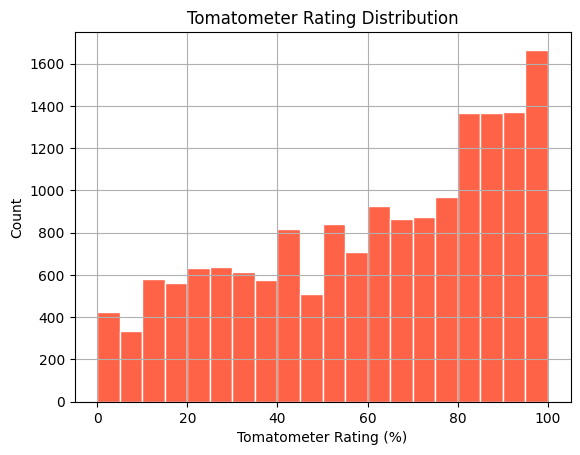

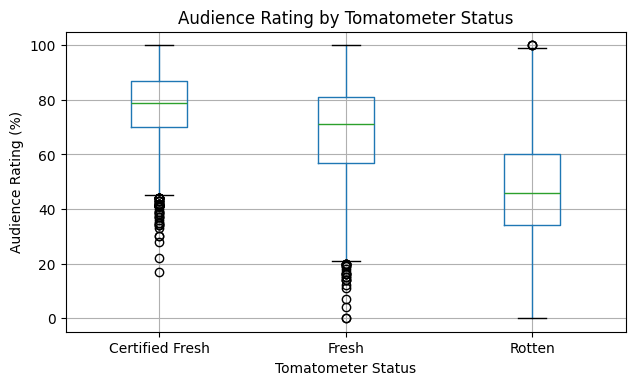

In [9]:
# Histogram of tomatometer_rating
df['tomatometer_rating'].hist(bins=20, color='tomato', edgecolor='white')
plt.title("Tomatometer Rating Distribution")
plt.xlabel("Tomatometer Rating (%)")
plt.ylabel("Count")
plt.show()

# Boxplot of audience_rating by tomatometer_status
df.boxplot(column='audience_rating', by='tomatometer_status',
           positions=[0, 1, 2], figsize=(7, 4))
plt.title("Audience Rating by Tomatometer Status")
plt.suptitle("")
plt.xlabel("Tomatometer Status")
plt.ylabel("Audience Rating (%)")
plt.show()

### 7.1. Forma numérica de la distribución
Para no depender solo de la forma visual del histograma, calculamos media, mediana y el peso de varios rangos del Tomatometer. Así podemos ver si la masa está realmente en la parte alta del rango o si hay también una concentración importante en notas bajas.

In [10]:
import pandas as pd

if 'df' not in globals():
    import pathlib
    import sys
    sys.path.insert(0, str(pathlib.Path('../').resolve()))

    from src.config import RAW_PATH
    from src.io import load_csv
    from src.cleaning import clean

    df = clean(load_csv(RAW_PATH))

s = df['tomatometer_rating']

pct_lt_40 = (s < 40).mean() * 100
pct_40_59 = ((s >= 40) & (s < 60)).mean() * 100
pct_60_79 = ((s >= 60) & (s < 80)).mean() * 100
pct_ge_80 = (s >= 80).mean() * 100

print(f"Media:   {s.mean():.2f}")
print(f"Mediana: {s.median():.0f}")
print()
print(f"Distribución por rangos:")
print(f"- Menor que 40: {pct_lt_40:.1f}%")
print(f"- Entre 40 y 59: {pct_40_59:.1f}%")
print(f"- Entre 60 y 79: {pct_60_79:.1f}%")
print(f"- 80 o más: {pct_ge_80:.1f}%")

bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
counts = pd.cut(s, bins=bins, include_lowest=True).value_counts().sort_index()
display(counts.to_frame(name='peliculas'))

Media:   60.47
Mediana: 66

Distribución por rangos:
- Menor que 40: 26.2%
- Entre 40 y 59: 17.3%
- Entre 60 y 79: 21.8%
- 80 o más: 34.7%


,peliculas
tomatometer_rating,
"(-0.001, 10.0]",850
"(10.0, 20.0]",1282
"(20.0, 30.0]",1133
"(30.0, 40.0]",1371
"(40.0, 50.0]",1444
"(50.0, 60.0]",1455
"(60.0, 70.0]",1637
"(70.0, 80.0]",2099
"(80.0, 90.0]",2609


## 8. Análisis univariado – variables categóricas
Aquí distinguimos dos preguntas distintas:
- **Composición del catálogo**: cuántas películas hay por categoría (frecuencia).
- **Preferencia del público**: qué géneros reciben mejor valoración promedio.

En Q3 priorizamos la segunda (géneros mejor valorados), y luego añadimos una comparación de "géneros más visualizados" en términos proporcionales para evitar sesgos por volumen.

Además, mostramos la distribución MPAA como contexto descriptivo del tipo de contenido presente en el dataset.

**Qué significa cada etiqueta MPAA (resumen):**
- `G`: público general.
- `PG`: se sugiere guía parental.
- `PG-13`: contenido potencialmente no apto para menores de 13 sin supervisión.
- `R`: menores de 17 acompañados por adulto.
- `NC17`: solo adultos (17+).
- `NR`: no clasificada oficialmente.

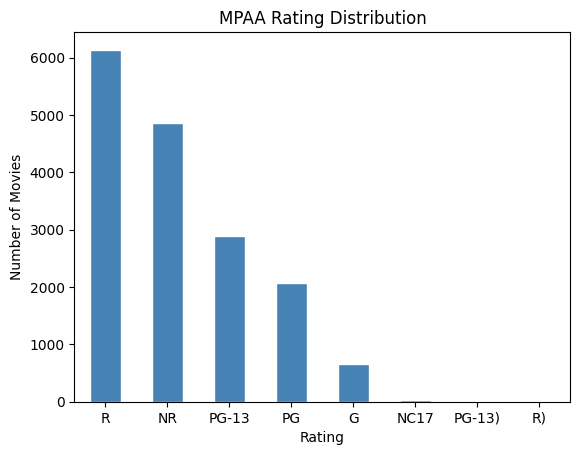

In [11]:
# Bar plot for MPAA rating
df["rating"].value_counts().plot(kind="bar", color="steelblue", edgecolor="white")
plt.title("MPAA Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")
plt.xticks(rotation=0)
plt.show()

### 8.1 Géneros que más gusta al público (controlando tamaño de muestra)
El top por frecuencia responde "qué hay más"; esta vista responde "qué suele gustar más".

Para evitar sesgos por géneros con muy pocas películas, filtramos géneros con al menos 50 títulos y ordenamos por media de `audience_rating`.

,primary_genre_raw,n_movies,mean_audience_rating,median_audience_rating
6,Documentary,1583,73.912986,77.0
3,Classics,1066,72.061090,76.5
2,Art House & International,1956,67.182618,71.0
1,Animation,344,64.166667,65.0
7,Drama,3510,60.221482,62.0
0,Action & Adventure,3353,57.663473,58.0
4,Comedy,3540,55.535940,55.0
11,Mystery & Suspense,261,46.861004,45.0
8,Horror,857,41.994041,39.0


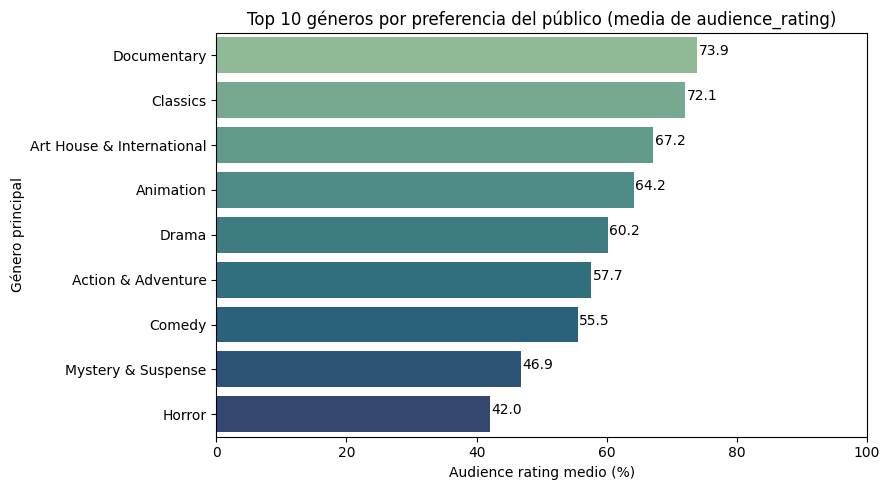

In [12]:
# Género principal para análisis de preferencia
_pref = df.copy()
_pref['primary_genre_raw'] = _pref['genre'].fillna('Unknown').str.split(',').str[0].str.strip()

genre_pref = (
    _pref.groupby('primary_genre_raw', as_index=False)
    .agg(
        n_movies=('movie_title', 'count'),
        mean_audience_rating=('audience_rating', 'mean'),
        median_audience_rating=('audience_rating', 'median')
    )
)

# Control de tamaño muestral para evitar rankings por géneros con muy pocas películas
genre_pref = genre_pref[genre_pref['n_movies'] >= 50].copy()
top_preferred = genre_pref.sort_values('mean_audience_rating', ascending=False).head(10)

display(top_preferred)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=top_preferred,
    x='mean_audience_rating',
    y='primary_genre_raw',
    hue='primary_genre_raw',
    palette='crest',
    legend=False,
)

for i, row in top_preferred.reset_index(drop=True).iterrows():
    ax.text(row['mean_audience_rating'] + 0.2, i, f"{row['mean_audience_rating']:.1f}")

plt.title('Top 10 géneros por preferencia del público (media de audience_rating)')
plt.xlabel('Audience rating medio (%)')
plt.ylabel('Género principal')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

### 8.2 Géneros más visualizados: total vs proporción
Para medir "qué género se ve más" sin caer en sesgo por volumen de títulos, comparamos:
- **Audiencia total** (`total_audience`): magnitud agregada.
- **Audiencia media por película** (`mean_audience_count`): métrica proporcional.

Aplicamos un mínimo de 50 películas por género para evitar conclusiones basadas en muestras pequeñas.

,primary_genre_raw,n_movies,total_audience,mean_audience_count,median_audience_count
1,Animation,344,142095747.0,415484.640351,21423.5
0,Action & Adventure,3353,900429588.0,269589.697006,11901.0
4,Comedy,3540,886165199.0,254791.604083,8275.5
7,Drama,3510,360696016.0,104428.493341,4096.5
8,Horror,857,80434188.0,95869.115614,6595.0
11,Mystery & Suspense,261,12123486.0,46808.826255,2241.0
3,Classics,1066,18367245.0,17262.448308,3675.5
2,Art House & International,1956,14956803.0,7737.611485,2461.0
6,Documentary,1583,6985376.0,4604.730389,666.0


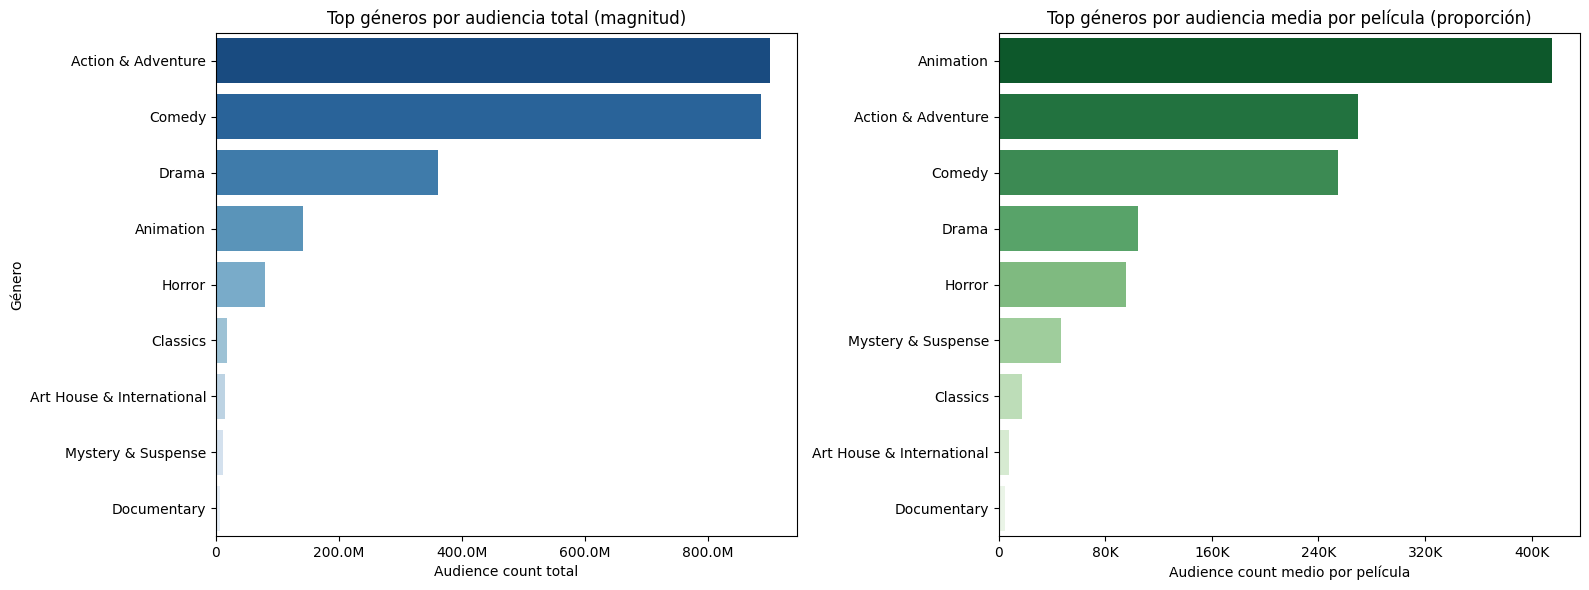

Lectura: usa la gráfica de proporción (derecha) para comparar géneros de forma justa.


In [13]:
from matplotlib.ticker import FuncFormatter, MaxNLocator


def format_compact(x, _pos):
    if abs(x) >= 1_000_000:
        return f"{x / 1_000_000:.1f}M"
    if abs(x) >= 1_000:
        return f"{x / 1_000:.0f}K"
    return f"{x:.0f}"


_views = df.copy()
_views['primary_genre_raw'] = _views['genre'].fillna('Unknown').str.split(',').str[0].str.strip()

genre_views = (
    _views.groupby('primary_genre_raw', as_index=False)
    .agg(
        n_movies=('movie_title', 'count'),
        total_audience=('audience_count', 'sum'),
        mean_audience_count=('audience_count', 'mean'),
        median_audience_count=('audience_count', 'median')
    )
)

# Umbral de robustez muestral
genre_views = genre_views[genre_views['n_movies'] >= 50].copy()

top_total = genre_views.sort_values('total_audience', ascending=False).head(10)
top_prop = genre_views.sort_values('mean_audience_count', ascending=False).head(10)

display(
    genre_views.sort_values('mean_audience_count', ascending=False)
    [['primary_genre_raw', 'n_movies', 'total_audience', 'mean_audience_count', 'median_audience_count']]
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=top_total,
    x='total_audience', y='primary_genre_raw',
    hue='primary_genre_raw', palette='Blues_r', legend=False, ax=axes[0]
)
axes[0].set_title('Top géneros por audiencia total (magnitud)')
axes[0].set_xlabel('Audience count total')
axes[0].set_ylabel('Género')
axes[0].xaxis.set_major_locator(MaxNLocator(nbins=6))
axes[0].xaxis.set_major_formatter(FuncFormatter(format_compact))

sns.barplot(
    data=top_prop,
    x='mean_audience_count', y='primary_genre_raw',
    hue='primary_genre_raw', palette='Greens_r', legend=False, ax=axes[1]
)
axes[1].set_title('Top géneros por audiencia media por película (proporción)')
axes[1].set_xlabel('Audience count medio por película')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_locator(MaxNLocator(nbins=6))
axes[1].xaxis.set_major_formatter(FuncFormatter(format_compact))

plt.tight_layout()
plt.show()

print('Lectura: usa la gráfica de proporción (derecha) para comparar géneros de forma justa.')

### 8.3 Robustez del ranking: mediana de visualizaciones por película
Para comprobar que el ranking proporcional no depende de outliers, usamos una métrica robusta: la **mediana** de `audience_count` por película.

Mantenemos el mismo umbral mínimo de 50 películas por género.

,primary_genre_raw,n_movies,mean_audience_count,median_audience_count
1,Animation,344,415484.640351,21423.5
0,Action & Adventure,3353,269589.697006,11901.0
4,Comedy,3540,254791.604083,8275.5
8,Horror,857,95869.115614,6595.0
7,Drama,3510,104428.493341,4096.5
3,Classics,1066,17262.448308,3675.5
2,Art House & International,1956,7737.611485,2461.0
11,Mystery & Suspense,261,46808.826255,2241.0
6,Documentary,1583,4604.730389,666.0


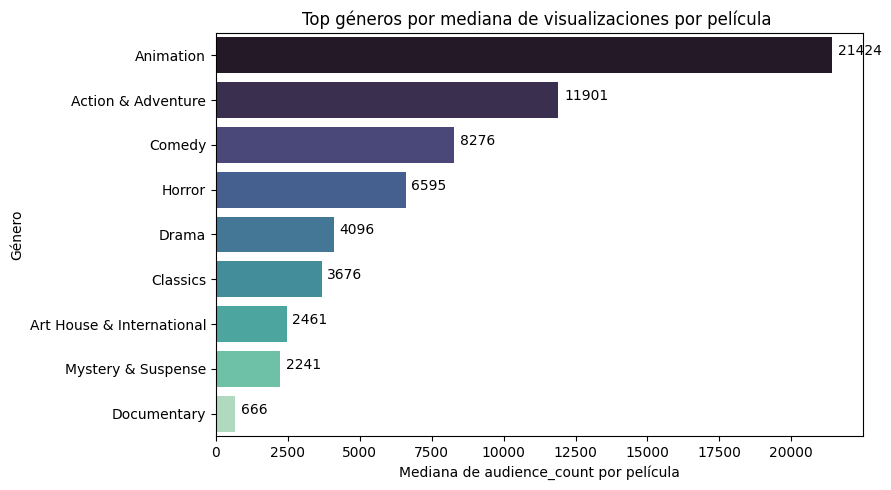

Si este ranking se parece al de media por película, la conclusión es más robusta.


In [14]:
top_median = genre_views.sort_values('median_audience_count', ascending=False).head(10)

display(top_median[['primary_genre_raw', 'n_movies', 'mean_audience_count', 'median_audience_count']])

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    data=top_median,
    x='median_audience_count',
    y='primary_genre_raw',
    hue='primary_genre_raw',
    palette='mako',
    legend=False,
)

for i, row in top_median.reset_index(drop=True).iterrows():
    ax.text(row['median_audience_count'] + 200, i, f"{row['median_audience_count']:.0f}")

plt.title('Top géneros por mediana de visualizaciones por película ')
plt.xlabel('Mediana de audience_count por película')
plt.ylabel('Género')
plt.tight_layout()
plt.show()

print('Si este ranking se parece al de media por película, la conclusión es más robusta.')

## 9. Análisis bivariado
El scatter Tomatometer vs Audience muestra si ambas puntuaciones se alinean o divergen. La nube de puntos tiene cierta correlación positiva pero con mucha dispersión, especialmente en los extremos. El crosstab MPAA × status muestra qué clasificaciones tienden a recibir mejores críticas.

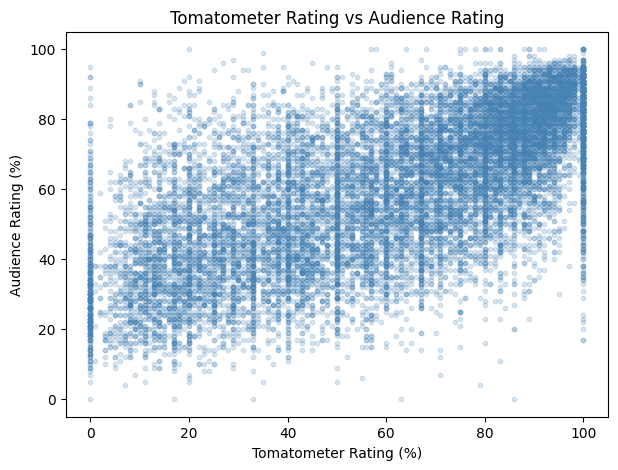

n = 16,638
corr = 0.660


tomatometer_status,Certified Fresh,Fresh,Rotten
rating,,,
G,124,336,192
NC17,7,19,11
NR,576,3081,1205
PG,376,753,933
PG-13,562,593,1730
PG-13),1,0,2
R,1311,1665,3160
R),0,1,0


In [15]:
# Scatter: tomatometer_rating vs audience_rating
x = df['tomatometer_rating']
y = df['audience_rating']

n = len(df)
corr_xy = x.corr(y)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.2, s=10, color='steelblue')
plt.title("Tomatometer Rating vs Audience Rating")
plt.xlabel("Tomatometer Rating (%)")
plt.ylabel("Audience Rating (%)")
plt.show()

print(f"n = {n:,}")
print(f"corr = {corr_xy:.3f}")

# Crosstab: MPAA rating × tomatometer_status
pd.crosstab(df['rating'], df['tomatometer_status'])

## 10. Correlaciones numéricas
Primer heatmap con las variables numéricas básicas del dato crudo. Útil para ver si `runtime_in_minutes` influye en las puntuaciones (spoiler: correlación baja) y si `tomatometer_count` y `audience_count` están relacionados con las valoraciones.

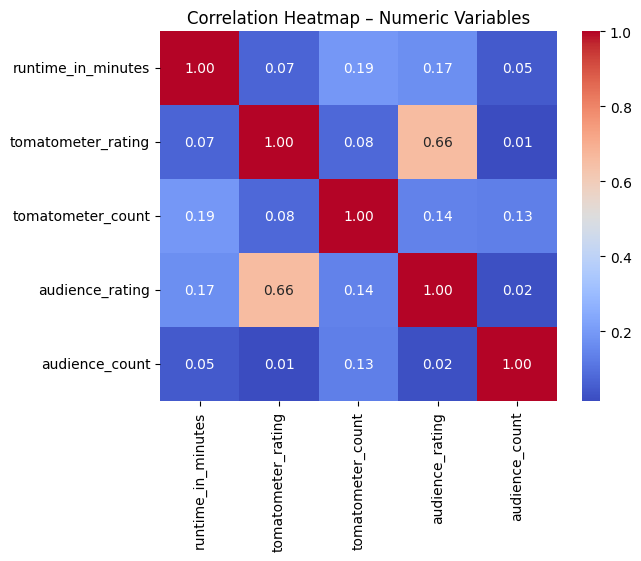

In [16]:
# Correlation matrix of numeric columns
numeric_cols = ['runtime_in_minutes', 'tomatometer_rating', 'tomatometer_count',
                'audience_rating', 'audience_count']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap – Numeric Variables")
plt.show()

### 10.1 Heatmap extendido con `audience_vs_critics`
Este heatmap puede incluir la feature `audience_vs_critics` (diferencia entre puntuación del público y de la crítica) **si ya se ejecutó la sección 12**. Si aún no se creó esa feature, el bloque usa las columnas numéricas disponibles y muestra una nota informativa.

### 10.2 Medias por grupo (género, año, estudio)
Las variables categóricas no pueden entrar directamente en un heatmap de correlación de Pearson. Aquí usamos el dato crudo para calcular medias por género, año y estudio antes de crear features nuevas.

In [17]:
import pandas as pd

_df = df.copy()

# Crear una versión simple del género principal sin depender de la feature posterior
_df['primary_genre_raw'] = _df['genre'].fillna('Unknown').str.split(',').str[0].str.strip()

# 1. Media de ratings y recuentos por género principal (top 8)
top_genres = _df['primary_genre_raw'].value_counts().nlargest(8).index
genre_stats = _df[_df['primary_genre_raw'].isin(top_genres)].groupby('primary_genre_raw')[['tomatometer_rating', 'audience_rating', 'audience_count']].mean().sort_values('tomatometer_rating', ascending=False)
display(genre_stats)

# 2. Media de ratings y recuentos por año de estreno (últimos 20 años)
_df['in_theaters_date'] = pd.to_datetime(_df['in_theaters_date'], errors='coerce')
_df['theater_year_raw'] = _df['in_theaters_date'].dt.year
year_stats = _df.groupby('theater_year_raw')[['tomatometer_rating', 'audience_rating', 'audience_count']].mean().tail(20)
display(year_stats)

# 3. Media de ratings y recuentos por estudio (top 10 estudios)
top_studios = _df['studio_name'].fillna('Unknown').value_counts().nlargest(10).index
studio_stats = _df[_df['studio_name'].fillna('Unknown').isin(top_studios)].groupby(_df['studio_name'].fillna('Unknown'))[['tomatometer_rating', 'audience_rating', 'audience_count']].mean().sort_values('tomatometer_rating', ascending=False)
display(studio_stats)

,tomatometer_rating,audience_rating,audience_count
primary_genre_raw,,,
Documentary,81.017688,73.912986,4604.730389
Classics,80.104128,72.061090,17262.448308
Art House & International,71.760225,67.182618,7737.611485
Animation,62.296512,64.166667,415484.640351
Drama,59.331624,60.221482,104428.493341
Action & Adventure,53.916194,57.663473,269589.697006
Comedy,50.928814,55.535940,254791.604083
Horror,45.367561,41.994041,95869.115614


,tomatometer_rating,audience_rating,audience_count
theater_year_raw,,,
2000.0,52.058252,59.569079,3.071792e+05
2001.0,53.467085,61.967949,4.164848e+05
2002.0,53.360795,60.244253,6.447336e+05
2003.0,53.859599,60.627907,8.642809e+05
2004.0,53.534351,62.007712,8.571723e+05
2005.0,54.317536,63.211031,1.042574e+06
2006.0,53.567515,62.082515,1.255194e+05
2007.0,57.510851,62.050336,1.453165e+05
2008.0,56.318008,57.373308,9.327924e+04


,tomatometer_rating,audience_rating,audience_count
studio_name,,,
Netflix,72.621429,61.413223,1004.252066
Unknown,68.765957,60.386423,2594.488251
IFC Films,63.763819,55.614610,7967.607053
Paramount Pictures,60.694165,63.434608,580849.547284
MGM,58.763359,62.249042,52412.716475
Universal Pictures,57.311301,62.119403,714253.000000
Warner Bros. Pictures,56.939024,63.242857,634143.997959
Warner Home Video,52.752089,58.706704,37898.469274
20th Century Fox,52.591787,60.562802,511045.719807


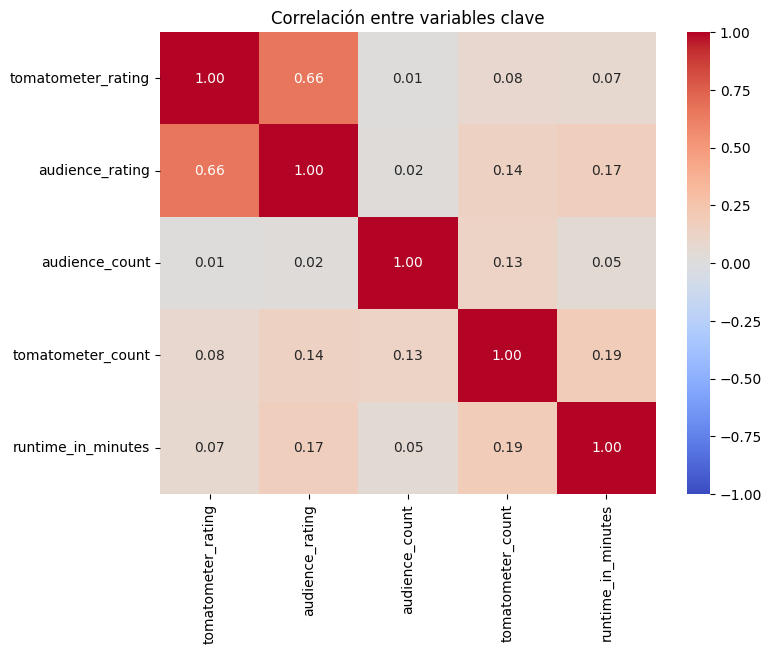

Nota: audience_vs_critics se añade en la sección 12. Este heatmap usa las columnas disponibles hasta este punto.


In [18]:
# Usar df_feat si existe, sino df
_df = df_feat if 'df_feat' in globals() else df

candidate_cols = [
    'tomatometer_rating', 'audience_rating', 'audience_count',
    'tomatometer_count', 'runtime_in_minutes', 'audience_vs_critics'
]
cols = [c for c in candidate_cols if c in _df.columns]

corr2 = _df[cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr2, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlación entre variables clave")
plt.show()

if 'audience_vs_critics' not in _df.columns:
    print("Nota: audience_vs_critics se añade en la sección 12. Este heatmap usa las columnas disponibles hasta este punto.")

## 11. Limpieza y transformaciones (`src/cleaning.py`)
Aquí aplicamos de forma reproducible las correcciones detectadas en la sección 6 sobre el dato crudo:
- **Typos en `rating`**: `PG-13)` y `R)` con paréntesis sobrante -> corregidos con `str.replace`.
- **`tomatometer_status`**: no presenta typos como `)`; sus valores válidos son `Rotten`, `Fresh` y `Certified Fresh`.
- **Duplicados**: 1 fila exactamente duplicada -> eliminada.
- **Fechas**: `in_theaters_date` y `on_streaming_date` pasan de `object` a `datetime`.
- **Nulos**: campos de texto se rellenan con `'Unknown'`/`'No consensus'`; filas sin `runtime_in_minutes` o `audience_rating` se eliminan (son esenciales para el análisis).
- **Categoría ordenada**: `tomatometer_status` -> `Categorical` con orden `Rotten < Fresh < Certified Fresh`.

In [19]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('../').resolve()))

from src.cleaning import clean

df_clean = clean(df)
print(f"After cleaning: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"Duplicates remaining: {df_clean.duplicated().sum()}")
print(f"Nulls remaining:\n{df_clean.isnull().sum()[df_clean.isnull().sum() > 0]}")
display(df_clean[['rating', 'tomatometer_status', 'in_theaters_date']].head())

After cleaning: 16,238 rows × 17 columns
Duplicates remaining: 0
Nulls remaining:
movie_info            16
in_theaters_date     694
on_streaming_date      1
dtype: int64


,rating,tomatometer_status,in_theaters_date
0,PG,Rotten,2010-02-12
1,R,Certified Fresh,2010-04-30
2,R,Fresh,1979-10-05
3,NR,Certified Fresh,1957-04-13
4,G,Fresh,1954-01-01


## 12. Construcción de features (`src/features.py`)
Creamos 3 variables derivadas que añaden información no presente directamente en el CSV:
- **`theater_year`**: año de estreno, para análisis temporal.
- **`audience_vs_critics`**: diferencia `audience_rating − tomatometer_rating`. Positivo = el público fue más generoso que la crítica.
- **`primary_genre`**: el primer género de la lista separada por comas, para simplificar el análisis categórico de géneros.

In [20]:
from src.features import build_features

df_feat = build_features(df_clean)
print("New columns:", ['theater_year', 'audience_vs_critics', 'primary_genre'])
display(df_feat[['movie_title', 'theater_year', 'audience_vs_critics', 'primary_genre']].head(10))

New columns: ['theater_year', 'audience_vs_critics', 'primary_genre']


,movie_title,theater_year,audience_vs_critics,primary_genre
0,Percy Jackson & the Olympians: The Lightning T...,2010.0,4.0,Action & Adventure
1,Please Give,2010.0,-22.0,Comedy
2,10,1979.0,-15.0,Comedy
3,12 Angry Men (Twelve Angry Men),1957.0,-3.0,Classics
4,"20,000 Leagues Under The Sea",1954.0,-15.0,Action & Adventure
5,"10,000 B.C.",2008.0,29.0,Action & Adventure
6,The 39 Steps,1935.0,-10.0,Action & Adventure
7,3:10 to Yuma,1957.0,-18.0,Classics
8,Charly (A Heartbeat Away),2002.0,67.0,Comedy
9,Abraham Lincoln,1930.0,-52.0,Classics


### 12.1 Respuesta directa a Q4: películas con mayor discrepancia
Mostramos dos rankings: 
- películas donde el **público** puntuó mucho más alto que la crítica (`audience_vs_critics` alto)
- películas donde la **crítica** puntuó mucho más alto que el público (`audience_vs_critics` bajo)

In [21]:
q4_cols = ['movie_title', 'tomatometer_rating', 'audience_rating', 'audience_vs_critics', 'rating', 'primary_genre']

# Top 10: público puntúa más alto que la crítica
q4_publico_mas = df_feat[q4_cols].sort_values('audience_vs_critics', ascending=False).head(10)

# Top 10: crítica puntúa más alto que el público
q4_critica_mas = df_feat[q4_cols].sort_values('audience_vs_critics', ascending=True).head(10)

print('Top 10 discrepancias a favor del PÚBLICO (Audience - Tomatometer):')
display(q4_publico_mas)

print('Top 10 discrepancias a favor de la CRÍTICA (Audience - Tomatometer):')
display(q4_critica_mas)

Top 10 discrepancias a favor del PÚBLICO (Audience - Tomatometer):


,movie_title,tomatometer_rating,audience_rating,audience_vs_critics,rating,primary_genre
1976,96 Souls,0,95.0,95.0,NR,Drama
7863,Is That a Gun in Your Pocket?,0,92.0,92.0,R,Comedy
7009,Hating Breitbart,0,92.0,92.0,PG-13,Documentary
1725,Home,0,86.0,86.0,NR,Documentary
1131,Fall,0,84.0,84.0,R,Comedy
716,Sparkle,10,91.0,81.0,PG,Drama
2410,All Relative,10,90.0,80.0,NR,Comedy
2142,A Violent Separation,10,90.0,80.0,NR,Drama
11312,Rainbow Brite and the Star Stealer,0,79.0,79.0,G,Animation
7667,In God's Hands,0,79.0,79.0,PG-13,Action & Adventure


Top 10 discrepancias a favor de la CRÍTICA (Audience - Tomatometer):


,movie_title,tomatometer_rating,audience_rating,audience_vs_critics,rating,primary_genre
10639,Outside the Law,86,0.0,-86.0,R,Action & Adventure
8395,Knock Down the House,100,17.0,-83.0,PG,Documentary
5707,Everybody Knows... Elizabeth Murray,100,17.0,-83.0,NR,Documentary
15456,Vengeance Valley,100,20.0,-80.0,PG,Action & Adventure
6921,Hannah Gadsby: Nanette,100,22.0,-78.0,NR,Comedy
15063,Traffic Stop,100,23.0,-77.0,NR,Documentary
4761,Daisy Miller,100,24.0,-76.0,G,Classics
2568,Amy Schumer Growing,79,4.0,-75.0,NR,Comedy
1507,Angel Rodriguez,83,11.0,-72.0,R,Art House & International
6912,Hangman,100,29.0,-71.0,NR,Horror


### 12.2 Comparativa director vs género (ajustada por volumen)
Esta comparación se realiza **después de limpieza y feature engineering** para mantener coherencia metodológica en la inferencia.

Se calculan, para cada director y género:
- `n_movies`: número de películas
- `total_audience`: suma de `audience_count` (popularidad total)
- `mean_audience` y `median_audience`: popularidad media por película (ajustada por volumen)

Así distinguimos:
- **efecto volumen** (muchas películas)
- **efecto rendimiento por película** (pocas películas, pero muy vistas)

Top 10 directores por audiencia total (ajustado con mínimo 5 películas):


,director_main,n_movies,total_audience,mean_audience,median_audience
6876,Steven Spielberg,32,76702161.0,2.396943e+06,368984.0
5736,Peter Jackson,12,72680080.0,6.056673e+06,318822.5
2640,Gore Verbinski,9,70759023.0,7.862114e+06,186973.0
3230,Jay Roach,12,69270766.0,5.772564e+06,121247.0
5762,Peter Segal,10,67326990.0,6.732699e+06,241954.5
4099,Keenen Ivory Wayans,6,66416334.0,1.106939e+07,551100.5
7077,Tim Burton,17,39702949.0,2.335468e+06,436369.0
6445,Sam Raimi,13,39675860.0,3.051989e+06,202565.0
3050,James Cameron,8,39145487.0,4.893186e+06,588739.0
6106,Ridley Scott,25,38909040.0,1.556362e+06,131093.0


Top géneros por audiencia total (mínimo 30 películas):


,genre_main,n_movies,total_audience,mean_audience,median_audience
0,Action & Adventure,3302,900099103.0,2.725921e+05,12135.5
4,Comedy,3440,885993626.0,2.575563e+05,8474.5
7,Drama,3418,360577660.0,1.054938e+05,4190.5
1,Animation,337,142036839.0,4.214743e+05,21712.0
8,Horror,824,80364938.0,9.753026e+04,6765.0
9,Kids & Family,43,70863399.0,1.647986e+06,22108.0
3,Classics,1064,18367245.0,1.726245e+04,3675.5
2,Art House & International,1930,14956380.0,7.749420e+03,2462.0
11,Mystery & Suspense,256,12120976.0,4.734756e+04,2345.5
6,Documentary,1510,6975837.0,4.619760e+03,670.5


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

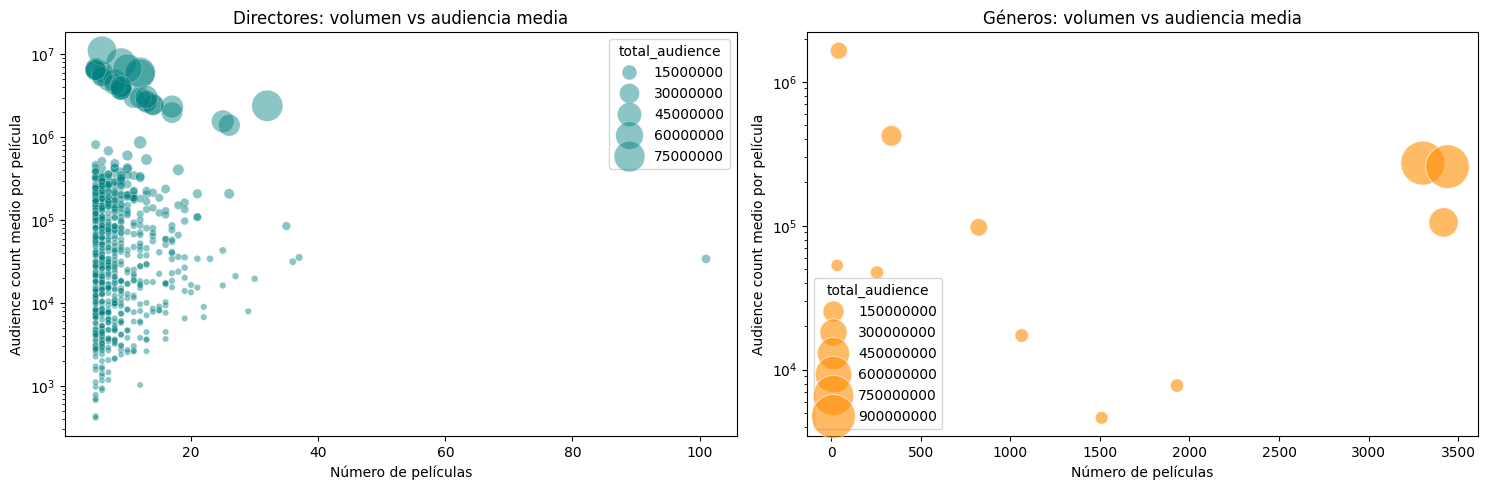

In [22]:
# Usar dato limpio con features para inferencia descriptiva
_df_cmp = df_feat.dropna(subset=['audience_count']).copy()

# Director y género principal
_df_cmp['director_main'] = _df_cmp['directors'].fillna('Unknown').str.split(',').str[0].str.strip()
_df_cmp['genre_main'] = _df_cmp['primary_genre'].fillna('Unknown').astype(str).str.strip()

# Agregados por director
director_stats = (
    _df_cmp.groupby('director_main', as_index=False)
    .agg(
        n_movies=('movie_title', 'count'),
        total_audience=('audience_count', 'sum'),
        mean_audience=('audience_count', 'mean'),
        median_audience=('audience_count', 'median')
    )
)
director_stats = director_stats[director_stats['n_movies'] >= 5].copy()

# Agregados por género
genre_stats_cmp = (
    _df_cmp.groupby('genre_main', as_index=False)
    .agg(
        n_movies=('movie_title', 'count'),
        total_audience=('audience_count', 'sum'),
        mean_audience=('audience_count', 'mean'),
        median_audience=('audience_count', 'median')
    )
)
genre_stats_cmp = genre_stats_cmp[genre_stats_cmp['n_movies'] >= 30].copy()

print('Top 10 directores por audiencia total (ajustado con mínimo 5 películas):')
display(director_stats.sort_values('total_audience', ascending=False).head(10))

print('Top géneros por audiencia total (mínimo 30 películas):')
display(genre_stats_cmp.sort_values('total_audience', ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(
    data=director_stats,
    x='n_movies', y='mean_audience',
    size='total_audience', sizes=(20, 500),
    alpha=0.45, color='teal', ax=axes[0]
)
axes[0].set_title('Directores: volumen vs audiencia media')
axes[0].set_xlabel('Número de películas')
axes[0].set_ylabel('Audience count medio por película')
axes[0].set_yscale('log')

sns.scatterplot(
    data=genre_stats_cmp,
    x='n_movies', y='mean_audience',
    size='total_audience', sizes=(80, 1000),
    alpha=0.60, color='darkorange', ax=axes[1]
)
axes[1].set_title('Géneros: volumen vs audiencia media')
axes[1].set_xlabel('Número de películas')
axes[1].set_ylabel('Audience count medio por película')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

### 12.3 ¿La audiencia responde más al director o al género?
Para aproximar esta pregunta de forma **justa y comparable**, usamos el mismo conjunto de películas limpias y una evaluación **fuera de muestra**.

Método:
- Variable objetivo: `log1p(audience_count)` (reduce asimetría).
- Modelo A: predicción usando solo `genre_main`.
- Modelo B: predicción usando solo `director_main`.
- En ambos casos, la predicción es la media del grupo aprendida en train (target mean encoding) y evaluada en test.
- Métrica: $R^2$ promedio en validación cruzada.

Si el $R^2$ de director es mayor, hay más señal asociada al director; si el de género es mayor, pesa más el género.

,factor,n_rows,n_groups,r2_mean_pct,r2_std_pct
0,Género,16238,18,12.292356,0.530489
1,Director,16238,7601,18.285267,2.411041


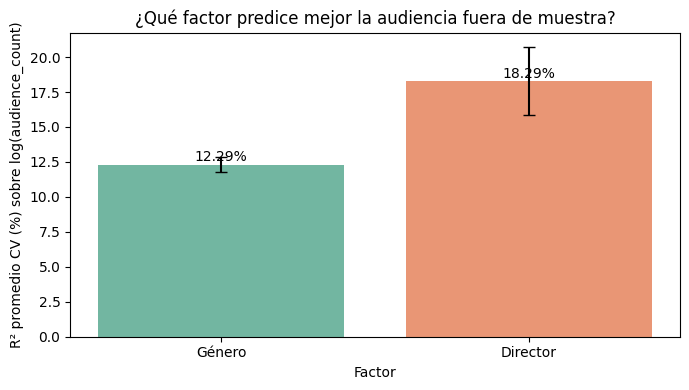

Resultado: en esta muestra, Director tiene mayor capacidad predictiva (R² CV medio = 18.29% ± 2.41).


In [23]:
# Mismo dataset limpio para ambos factores
cmp = _df_cmp[['audience_count', 'director_main', 'genre_main']].dropna().copy()
cmp['aud_log'] = np.log1p(cmp['audience_count'])

def r2_manual(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

def make_folds(n_rows, n_splits=5, seed=42):
    rng = np.random.default_rng(seed)
    idx = np.arange(n_rows)
    rng.shuffle(idx)
    return np.array_split(idx, n_splits)

def cv_group_mean_r2(data, group_col, target_col='aud_log', n_splits=5, seed=42):
    folds = make_folds(len(data), n_splits=n_splits, seed=seed)

    r2_folds = []
    y_all = data[target_col].reset_index(drop=True)
    g_all = data[group_col].reset_index(drop=True)

    for test_idx in folds:
        train_mask = np.ones(len(data), dtype=bool)
        train_mask[test_idx] = False

        x_train = g_all[train_mask]
        y_train = y_all[train_mask]
        x_test = g_all.iloc[test_idx]
        y_test = y_all.iloc[test_idx]

        global_mean = y_train.mean()
        group_means = y_train.groupby(x_train).mean()

        y_pred = x_test.map(group_means).fillna(global_mean)
        r2_folds.append(r2_manual(y_test.values, y_pred.values))

    return {
        'factor': group_col,
        'r2_mean': float(np.mean(r2_folds)),
        'r2_std': float(np.std(r2_folds)),
        'n_rows': int(len(data)),
        'n_groups': int(data[group_col].nunique()),
    }

res_genre = cv_group_mean_r2(cmp, 'genre_main')
res_director = cv_group_mean_r2(cmp, 'director_main')

summary_cv = pd.DataFrame([
    {'factor': 'Género', **{k: v for k, v in res_genre.items() if k != 'factor'}},
    {'factor': 'Director', **{k: v for k, v in res_director.items() if k != 'factor'}},
])

summary_cv['r2_mean_pct'] = summary_cv['r2_mean'] * 100
summary_cv['r2_std_pct'] = summary_cv['r2_std'] * 100
display(summary_cv[['factor', 'n_rows', 'n_groups', 'r2_mean_pct', 'r2_std_pct']])

plt.figure(figsize=(7, 4))
ax = sns.barplot(data=summary_cv, x='factor', y='r2_mean_pct', hue='factor', palette='Set2', legend=False)

for i, row in summary_cv.reset_index(drop=True).iterrows():
    ax.errorbar(i, row['r2_mean_pct'], yerr=row['r2_std_pct'], fmt='none', ecolor='black', capsize=4)
    ax.text(i, row['r2_mean_pct'] + 0.25, f"{row['r2_mean_pct']:.2f}%", ha='center')

plt.ylabel('R² promedio CV (%) sobre log(audience_count)')
plt.xlabel('Factor')
plt.title('¿Qué factor predice mejor la audiencia fuera de muestra?')
plt.tight_layout()
plt.show()

winner = summary_cv.sort_values('r2_mean', ascending=False).iloc[0]
print(
    f"Resultado: en esta muestra, {winner['factor']} tiene mayor capacidad predictiva "
    f"(R² CV medio = {winner['r2_mean_pct']:.2f}% ± {winner['r2_std_pct']:.2f})."
)

### Análisis del gap Audience − Critics
¿Quién puntúa más alto habitualmente, el público o la crítica?

Para **cada película** calculamos: `audience_rating − tomatometer_rating`

- Si el resultado es **negativo** → los críticos puntuaron más alto que el público en esa película
- Si el resultado es **positivo** → el público puntuó más alto que los críticos
- Si es **0** → puntuaron igual

Ejemplo concreto:
| Película | Tomatometer | Audience | Diferencia | ¿Quién ganó? |
|---|---|---|---|---|
| Película A | 70 | 65 | −5 | Crítica > Público |
| Película B | 50 | 72 | +22 | Público > Crítica |
| Película C | 80 | 80 | 0 | Empate |

Los porcentajes que aparecen en la gráfica simplemente cuentan **cuántas películas** caen en cada caso.

Media:   0.07 pts  ← casi cero, pero distorsionada por casos extremos
Mediana: -2.0 pts  ← el 50% de las películas tiene diferencia <= -2

En 54.1% de las películas: Tomatometer > Audience  (críticos más generosos)
En 44.0% de las películas: Audience > Tomatometer  (público más generoso)

Es decir: en más de la mitad de las películas del dataset,
los críticos les dieron una nota más alta que el público.


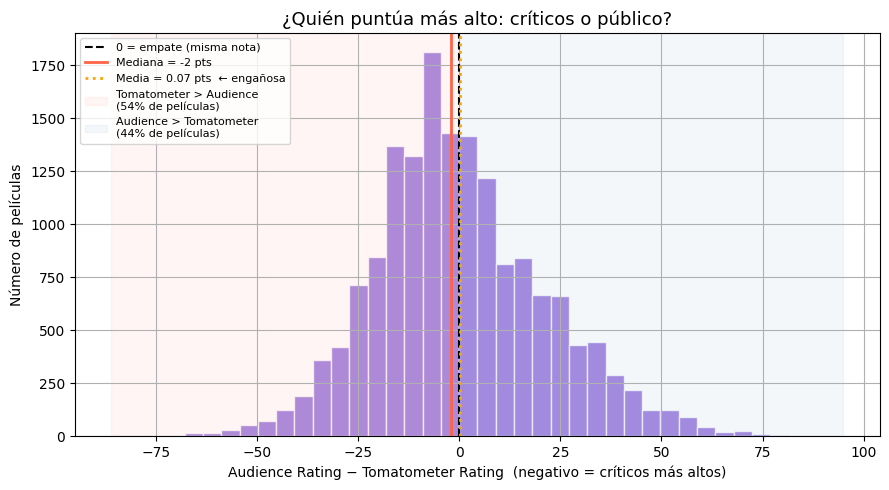

In [24]:
s = df_feat['audience_vs_critics']

media   = s.mean()
mediana = s.median()
pct_pos = (s > 0).mean() * 100
pct_neg = (s < 0).mean() * 100

print(f"Media:   {media:.2f} pts  ← casi cero, pero distorsionada por casos extremos")
print(f"Mediana: {mediana:.1f} pts  ← el 50% de las películas tiene diferencia <= -2")
print()
print(f"En {pct_neg:.1f}% de las películas: Tomatometer > Audience  (críticos más generosos)")
print(f"En {pct_pos:.1f}% de las películas: Audience > Tomatometer  (público más generoso)")
print()
print("Es decir: en más de la mitad de las películas del dataset,")
print("los críticos les dieron una nota más alta que el público.")

# Gráfica anotada
fig, ax = plt.subplots(figsize=(9, 5))
s.hist(bins=40, color='mediumpurple', edgecolor='white', alpha=0.8, ax=ax)

ax.axvline(0,       color='black',  linestyle='--', linewidth=1.5, label='0 = empate (misma nota)')
ax.axvline(mediana, color='tomato', linestyle='-',  linewidth=2,   label=f'Mediana = {mediana:.0f} pts')
ax.axvline(media,   color='orange', linestyle=':',  linewidth=2,   label=f'Media = {media:.2f} pts  ← engañosa')

ax.axvspan(s.min(), 0, alpha=0.06, color='tomato',
           label=f'Tomatometer > Audience\n({pct_neg:.0f}% de películas)')
ax.axvspan(0, s.max(), alpha=0.06, color='steelblue',
           label=f'Audience > Tomatometer\n({pct_pos:.0f}% de películas)')

ax.set_title("¿Quién puntúa más alto: críticos o público?", fontsize=13)
ax.set_xlabel("Audience Rating − Tomatometer Rating  (negativo = críticos más altos)")
ax.set_ylabel("Número de películas")
ax.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

### 12.4 Evolución del visionado medio por película y año

Esta gráfica compara años usando la **media de `audience_count` por película** (no el total anual), evitando el sesgo de que algunos años tengan más títulos que otros.

También se muestra cuántas películas hay por año para contextualizar la estabilidad del promedio.

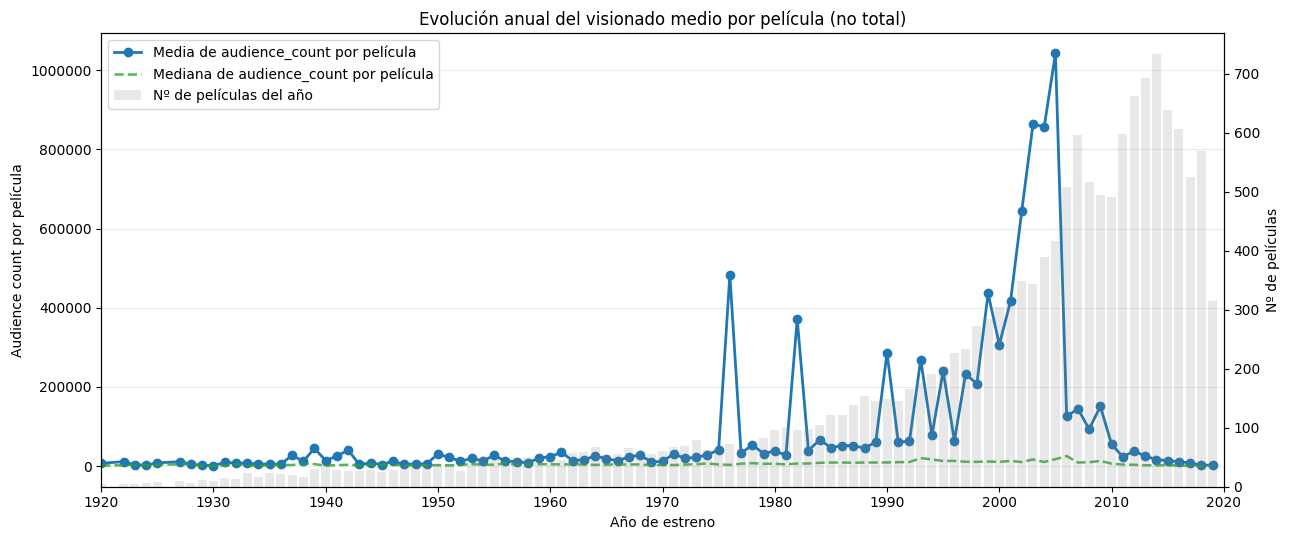

,theater_year,n_movies,mean_audience_count,median_audience_count
92,2008,517,93279.235977,9746.0
93,2009,495,151139.030303,13304.0
94,2010,491,55177.085540,6229.0
95,2011,598,23744.244147,3939.0
96,2012,663,38045.220211,3558.0
97,2013,693,25231.694084,2211.0
98,2014,733,16608.181446,1897.0
99,2015,639,13960.112676,2313.0
100,2016,606,11204.757426,1580.0
101,2017,526,8240.448669,907.0


In [25]:
# Base: dato limpio con features
_year_df = df_feat.dropna(subset=['theater_year', 'audience_count']).copy()
_year_df['theater_year'] = _year_df['theater_year'].astype(int)

# Agregado por año: promedio por película (métrica pedida) + conteo para contexto
year_mean_views = (
    _year_df.groupby('theater_year', as_index=False)
    .agg(
        n_movies=('movie_title', 'count'),
        mean_audience_count=('audience_count', 'mean'),
        median_audience_count=('audience_count', 'median')
    )
    .sort_values('theater_year')
)

# Opcional: filtrar años con muy pocas películas para evitar ruido extremo
year_mean_views = year_mean_views[year_mean_views['n_movies'] >= 5].copy()

fig, ax1 = plt.subplots(figsize=(13, 5.5))

ax1.plot(
    year_mean_views['theater_year'],
    year_mean_views['mean_audience_count'],
    color='tab:blue',
    marker='o',
    linewidth=2,
    label='Media de audience_count por película'
)
ax1.plot(
    year_mean_views['theater_year'],
    year_mean_views['median_audience_count'],
    color='tab:green',
    linestyle='--',
    linewidth=1.8,
    alpha=0.8,
    label='Mediana de audience_count por película'
)

ax1.set_title('Evolución anual del visionado medio por película (no total)')
ax1.set_xlabel('Año de estreno')

# Ticks del eje X cada 10 años para mejorar legibilidad
start_year = int(np.floor(year_mean_views['theater_year'].min() / 10) * 10)
end_year = int(np.ceil(year_mean_views['theater_year'].max() / 10) * 10)
ax1.set_xticks(np.arange(start_year, end_year + 1, 10))
ax1.set_xlim(start_year, end_year)

ax1.set_ylabel('Audience count por película')
ax1.ticklabel_format(style='plain', axis='y')
ax1.grid(True, axis='y', alpha=0.25)

# Eje secundario para mostrar cuántas películas hay por año
ax2 = ax1.twinx()
ax2.bar(
    year_mean_views['theater_year'],
    year_mean_views['n_movies'],
    color='gray',
    alpha=0.18,
    width=0.8,
    label='Nº de películas del año'
)
ax2.set_ylabel('Nº de películas')

# Leyenda combinada de ambos ejes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

display(year_mean_views.tail(12))

In [26]:
# Diagnóstico del pico 2005-2006 en mean_audience_count
_year_check = df_feat.dropna(subset=['theater_year', 'audience_count']).copy()
_year_check['theater_year'] = _year_check['theater_year'].astype(int)

for y in [2004, 2005, 2006, 2007]:
    s = _year_check.loc[_year_check['theater_year'] == y, 'audience_count']
    if len(s) == 0:
        continue
    print(f"\nAño {y}")
    print(f"n_movies: {len(s)}")
    print(f"mean: {s.mean():.0f}")
    print(f"median: {s.median():.0f}")
    print(f"p90: {s.quantile(0.90):.0f}")
    print(f"p95: {s.quantile(0.95):.0f}")
    print(f"max: {s.max():.0f}")

for y in [2005, 2006]:
    top = (
        _year_check[_year_check['theater_year'] == y]
        .sort_values('audience_count', ascending=False)
        [['movie_title', 'audience_count', 'tomatometer_rating', 'audience_rating', 'primary_genre']]
        .head(15)
    )
    print(f"\nTop 15 audience_count en {y}:")
    display(top)

# Cuánto pesa el top 5 en la media anual
for y in [2005, 2006]:
    s = _year_check.loc[_year_check['theater_year'] == y, 'audience_count'].sort_values(ascending=False)
    top5_share = s.head(5).sum() / s.sum() * 100
    print(f"En {y}, el top 5 concentra {top5_share:.1f}% del audience_count total del año.")


Año 2004
n_movies: 389
mean: 857172
median: 10527
p90: 424576
p95: 698263
max: 34232524

Año 2005
n_movies: 417
mean: 1042574
median: 17616
p90: 398077
p95: 481183
max: 34153607

Año 2006
n_movies: 509
mean: 125519
median: 25377
p90: 423840
p95: 541632
max: 1847651

Año 2007
n_movies: 596
mean: 145317
median: 9220
p90: 403490
p95: 605560
max: 2738491

Top 15 audience_count en 2005:


,movie_title,audience_count,tomatometer_rating,audience_rating,primary_genre
6988,Harry Potter and the Goblet of Fire,34153607.0,88,74.0,Action & Adventure
4284,"The Chronicles of Narnia: The Lion, The Witch ...",34105114.0,76,61.0,Kids & Family
8336,King Kong,33766734.0,84,50.0,Action & Adventure
12728,Star Wars: Episode III - Revenge of the Sith,33683838.0,80,66.0,Action & Adventure
9849,Mr. & Mrs. Smith,33461707.0,59,58.0,Action & Adventure
15690,Wedding Crashers,32961772.0,75,70.0,Comedy
8960,The Longest Yard,32774364.0,31,62.0,Comedy
7228,Hitch,32624083.0,68,62.0,Comedy
11901,Saw II,32524689.0,37,59.0,Horror
15615,War of the Worlds,32518946.0,75,42.0,Action & Adventure



Top 15 audience_count en 2006:


,movie_title,audience_count,tomatometer_rating,audience_rating,primary_genre
10959,Pirates of the Caribbean: Dead Man's Chest,1847651.0,53,72.0,Action & Adventure
3641,Borat: Cultural Learnings of America for Make ...,1204572.0,91,79.0,Comedy
16094,X-Men: The Last Stand,1074092.0,57,61.0,Action & Adventure
15407,V for Vendetta,903721.0,72,90.0,Action & Adventure
4057,Cars,877830.0,75,79.0,Action & Adventure
4380,Click,874657.0,33,66.0,Comedy
7571,Ice Age 2: The Meltdown,854368.0,57,71.0,Action & Adventure
4748,The Da Vinci Code,761284.0,25,57.0,Action & Adventure
5032,The Departed,737217.0,91,94.0,Action & Adventure
10203,Night at the Museum,723930.0,42,67.0,Action & Adventure


En 2005, el top 5 concentra 38.9% del audience_count total del año.
En 2006, el top 5 concentra 9.2% del audience_count total del año.


In [27]:
# Diagnóstico específico 2003-2005
_year_check2 = df_feat.dropna(subset=['theater_year', 'audience_count']).copy()
_year_check2['theater_year'] = _year_check2['theater_year'].astype(int)

for y in [2003, 2004, 2005]:
    s = _year_check2.loc[_year_check2['theater_year'] == y, 'audience_count']
    print(f"\nAño {y}")
    print(f"n_movies: {len(s)}")
    print(f"mean: {s.mean():.0f}")
    print(f"median: {s.median():.0f}")
    print(f"p90: {s.quantile(0.90):.0f}")
    print(f"p95: {s.quantile(0.95):.0f}")
    print(f"max: {s.max():.0f}")

    top5_share = s.sort_values(ascending=False).head(5).sum() / s.sum() * 100
    print(f"top5_share_total: {top5_share:.1f}%")

    top10 = (
        _year_check2[_year_check2['theater_year'] == y]
        .sort_values('audience_count', ascending=False)
        [['movie_title', 'audience_count']]
        .head(10)
    )
    display(top10)


Año 2003
n_movies: 344
mean: 864281
median: 16944
p90: 432754
p95: 557695
max: 34679773
top5_share_total: 56.2%


,movie_title,audience_count
14172,The Lord of the Rings: The Return of the King,34679773.0
6000,Finding Nemo,33356856.0
10962,Pirates of the Caribbean: The Curse of the Bla...,33125722.0
3842,Bruce Almighty,33024215.0
1878,2 Fast 2 Furious,32791717.0
11936,School of Rock,32784354.0
8285,Kill Bill: Volume 1,32558003.0
9037,Love Actually,31626919.0
16092,X2: X-Men United,977220.0
9419,The Matrix Reloaded,942408.0



Año 2004
n_movies: 389
mean: 857172
median: 10527
p90: 424576
p95: 698263
max: 34232524
top5_share_total: 49.7%


,movie_title,audience_count
12242,Shrek 2,34232524.0
9490,Meet the Fockers,33181885.0
4860,The Day After Tomorrow,32749429.0
1934,50 First Dates,32700188.0
15840,White Chicks,32691607.0
7730,The Incredibles,32604129.0
9469,Mean Girls,32167706.0
4309,A Cinderella Story,31659732.0
10348,The Notebook,31656590.0
6991,Harry Potter and the Prisoner of Azkaban,1167820.0



Año 2005
n_movies: 417
mean: 1042574
median: 17616
p90: 398077
p95: 481183
max: 34153607
top5_share_total: 38.9%


,movie_title,audience_count
6988,Harry Potter and the Goblet of Fire,34153607.0
4284,"The Chronicles of Narnia: The Lion, The Witch ...",34105114.0
8336,King Kong,33766734.0
12728,Star Wars: Episode III - Revenge of the Sith,33683838.0
9849,Mr. & Mrs. Smith,33461707.0
15690,Wedding Crashers,32961772.0
8960,The Longest Yard,32774364.0
7228,Hitch,32624083.0
11901,Saw II,32524689.0
15615,War of the Worlds,32518946.0


### 12.5 Películas que explican los picos (2003-2005) y tendencia de la mediana

En lugar de mirar solo la media, aquí:
- listamos las películas con mayor `audience_count` en los años pico (2003-2005),
- y analizamos la tendencia anual de la **mediana** de `audience_count` para representar la película "típica" de cada año.

Top 10 películas por audience_count en 2003, 2004 y 2005:


,theater_year,movie_title,audience_count,audience_rating,tomatometer_rating,primary_genre
14172,2003,The Lord of the Rings: The Return of the King,34679773.0,86.0,93,Action & Adventure
6000,2003,Finding Nemo,33356856.0,86.0,99,Animation
10962,2003,Pirates of the Caribbean: The Curse of the Bla...,33125722.0,86.0,79,Action & Adventure
3842,2003,Bruce Almighty,33024215.0,57.0,48,Comedy
1878,2003,2 Fast 2 Furious,32791717.0,50.0,36,Action & Adventure
11936,2003,School of Rock,32784354.0,64.0,91,Comedy
8285,2003,Kill Bill: Volume 1,32558003.0,81.0,85,Action & Adventure
9037,2003,Love Actually,31626919.0,72.0,63,Comedy
16092,2003,X2: X-Men United,977220.0,85.0,85,Action & Adventure
9419,2003,The Matrix Reloaded,942408.0,72.0,73,Mystery & Suspense


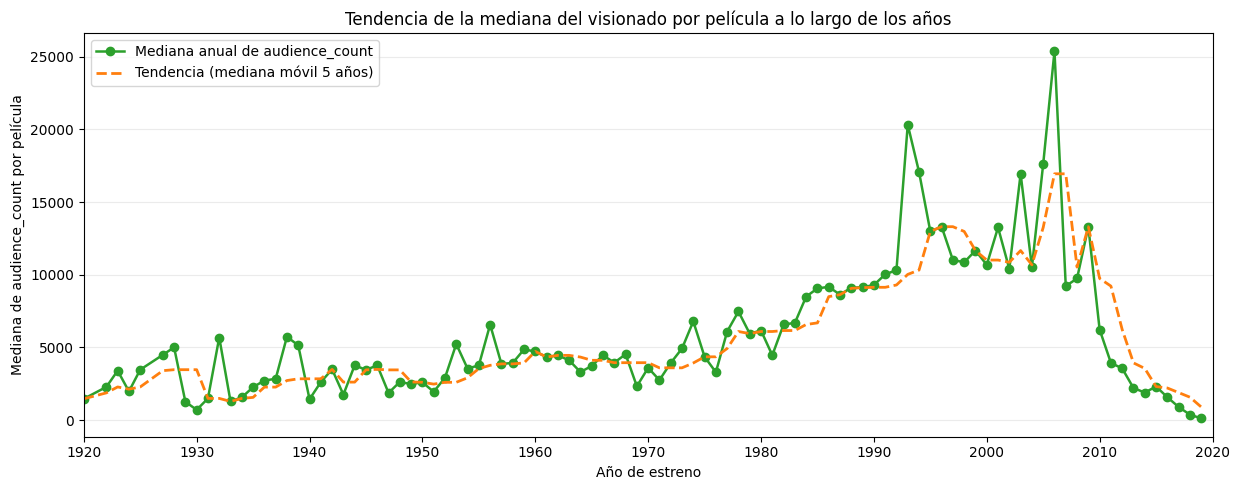

,theater_year,n_movies,median_audience_count,median_roll5
89,2005,417,17616.0,13252.0
90,2006,509,25377.0,16943.5
91,2007,596,9220.5,16943.5
92,2008,517,9746.0,10527.0
93,2009,495,13304.0,13304.0
94,2010,491,6229.0,9746.0
95,2011,598,3939.0,9220.5
96,2012,663,3558.0,6229.0
97,2013,693,2211.0,3939.0
98,2014,733,1897.0,3558.0


In [28]:
# Películas con mayor audience_count en los años pico
_year_focus = df_feat.dropna(subset=['theater_year', 'audience_count']).copy()
_year_focus['theater_year'] = _year_focus['theater_year'].astype(int)

peak_years = [2003, 2004, 2005]

top_peak_movies = (
    _year_focus[_year_focus['theater_year'].isin(peak_years)]
    .sort_values(['theater_year', 'audience_count'], ascending=[True, False])
    .groupby('theater_year', group_keys=False)
    .head(10)
    [['theater_year', 'movie_title', 'audience_count', 'audience_rating', 'tomatometer_rating', 'primary_genre']]
)

print('Top 10 películas por audience_count en 2003, 2004 y 2005:')
display(top_peak_movies)

# Tendencia de la mediana anual (película típica de cada año)
median_trend = (
    _year_focus.groupby('theater_year', as_index=False)
    .agg(
        n_movies=('movie_title', 'count'),
        median_audience_count=('audience_count', 'median')
    )
    .query('n_movies >= 5')
    .sort_values('theater_year')
)

median_trend['median_roll5'] = (
    median_trend['median_audience_count']
    .rolling(window=5, min_periods=1)
    .median()
)

plt.figure(figsize=(12.5, 5))
plt.plot(
    median_trend['theater_year'],
    median_trend['median_audience_count'],
    marker='o',
    linewidth=1.8,
    color='tab:green',
    label='Mediana anual de audience_count'
)
plt.plot(
    median_trend['theater_year'],
    median_trend['median_roll5'],
    linestyle='--',
    linewidth=2,
    color='tab:orange',
    label='Tendencia (mediana móvil 5 años)'
)

start_dec = int(np.floor(median_trend['theater_year'].min() / 10) * 10)
end_dec = int(np.ceil(median_trend['theater_year'].max() / 10) * 10)
plt.xticks(np.arange(start_dec, end_dec + 1, 10))
plt.xlim(start_dec, end_dec)

plt.title('Tendencia de la mediana del visionado por película a lo largo de los años')
plt.xlabel('Año de estreno')
plt.ylabel('Mediana de audience_count por película')
plt.grid(True, axis='y', alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

display(median_trend.tail(15))

## 13. Visualizaciones finales (`src/viz.py`)
Panel de 6 gráficas sobre el dataset limpio con features:
1. **Distribución del Tomatometer** – concentración clara en puntuaciones altas, con una cola hacia valores bajos; no se observa una bimodalidad clara.
2. **Top géneros por gap público − crítica** – compara la mediana de `audience_rating − tomatometer_rating` por género (con umbral mínimo de películas), para identificar en qué géneros el público es relativamente más generoso o más estricto que la crítica.
3. **Top 10 géneros por visualizaciones por película (proporcional)** – ranking por `audience_count` medio, con umbral mínimo de películas por género para evitar sesgo por muestras pequeñas.
4. **Tomatometer vs Audience (scatter)** – relación positiva clara entre ambas puntuaciones en el dataset limpio (**n = 16 238**, **corr = 0.661**). La dispersión indica que hay desacuerdos puntuales entre crítica y público, sobre todo en los extremos.
5. **Tendencia anual de la mediana de visionado** – evolución de la mediana de `audience_count` por año (con tendencia móvil de 5 años), una lectura más robusta que la media frente a outliers.
6. **Top géneros por preferencia del público (proporcional)** – ranking por media de `audience_rating` por género, con umbral mínimo de películas, para priorizar géneros mejor valorados sin sesgo por muestras pequeñas.

**Lectura conjunta (gráficas 2, 5 y 6):**
Las tres se complementan: la gráfica 2 muestra dónde cambia el desacuerdo público-crítica por género, la 5 contextualiza la evolución temporal del visionado típico, y la 6 resume qué géneros reciben mejor valoración del público.

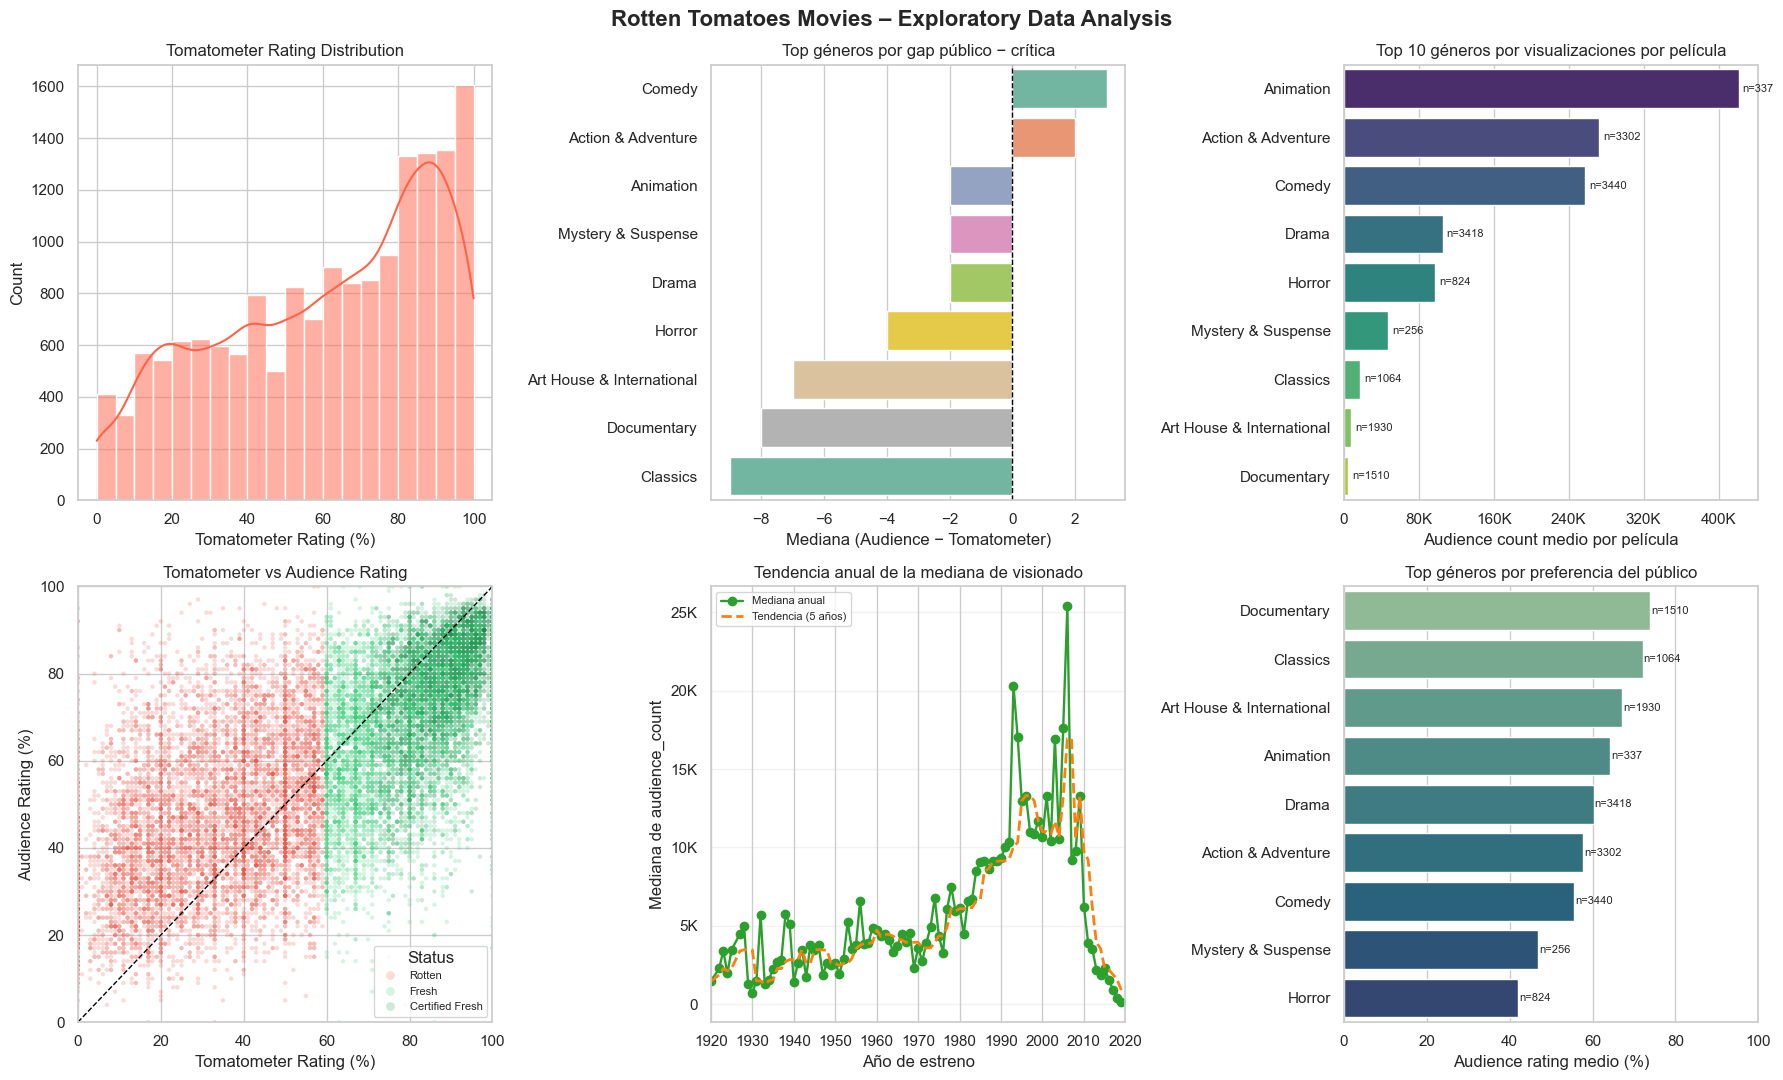

In [29]:
from pathlib import Path
import sys
import matplotlib
import importlib

# Ensure project root is on sys.path when running from notebooks/
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import src.viz as viz
viz = importlib.reload(viz)

# Build df_feat if the notebook kernel does not have it yet
if "df_feat" not in globals():
    from src.cleaning import clean
    from src.features import build_features
    from src.io import load_csv

    data_path = project_root / "data" / "raw" / "Rotten Tomatoes Movies.csv"
    df_feat = build_features(clean(load_csv(str(data_path))))

matplotlib.use("inline")  # render inline in notebook
viz.plot_graph(df_feat)